In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
all_data = pd.read_csv('data.csv')
all_data

,x,y,dataset
0,30,3932,train
1,31,4015,train
2,32,4108,train
3,33,4179,train
4,34,4265,train
...,...,...,...
106,110,10630,test
107,115,11040,test
108,120,11460,test
109,125,11875,test


In [3]:
train_data = all_data[all_data['dataset'] == 'train']
test_data = all_data[all_data['dataset'] == 'test']

In [4]:
train_x = train_data['x']
train_y = train_data['y']

In [5]:
def forward(a,b,x):
    return a*x + b

In [6]:
def loss(y,y_p):
    return (y_p - y)*(y_p - y)

In [7]:
a_set = np.arange(60,120.1,0.1)
b_set = np.arange(1400,1601,1)

In [8]:
w_list  = []
for a in a_set:
    w_x = []
    for b in b_set:
        w = 0
        for x,y in zip(train_x,train_y):
            pred_y = forward(a,b,x)
            w += loss(y,pred_y)
        w_x.append(w/len(train_x))
    w_list.append(w_x)


In [9]:
X,Y = np.meshgrid(b_set,a_set)
w_list = np.array(w_list)
w_list.min()

np.float64(41.74285714288883)

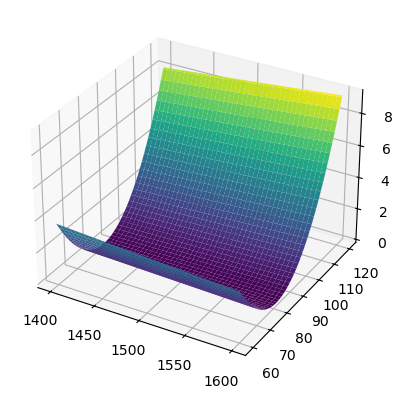

In [10]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, w_list, cmap='viridis')

plt.show()

In [11]:
#求得最佳
min_index = np.unravel_index(np.argmin(w_list), w_list.shape)
print("最小值坐标：", min_index)
print("最小值：", w_list[min_index])
a_min = a_set[min_index[0]]
b_min = b_set[min_index[1]]
print("a =", a_min, "b =", b_min)

最小值坐标： (np.int64(238), np.int64(26))
最小值： 41.74285714288883
a = 83.80000000000034 b = 1426


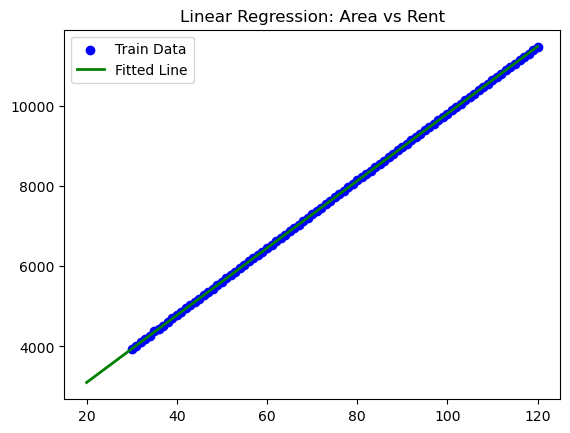

In [12]:
#拟合曲线与数据点
plt.scatter(train_x, train_y, color='blue', label='Train Data')
x_end = np.linspace(20,120,100)
y_end = x_end * a_min + b_min
plt.plot(x_end,y_end,color='green', linewidth=2, label='Fitted Line')
plt.legend()
plt.title('Linear Regression: Area vs Rent')
plt.show()